In [3]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

#from sklearn.preprocessing import StandardScaler

import random
from datetime import datetime
from scipy.stats import skewnorm
from IPython.display import clear_output
import re

import ipycytoscape
import torch

from pyvis.network import Network
import os
from datetime import datetime

DEBUG = True
WITH_NOISE = False
SAVE_PATH = "Sim_Raw_data.parquet"

2024-04-07 05:00:00


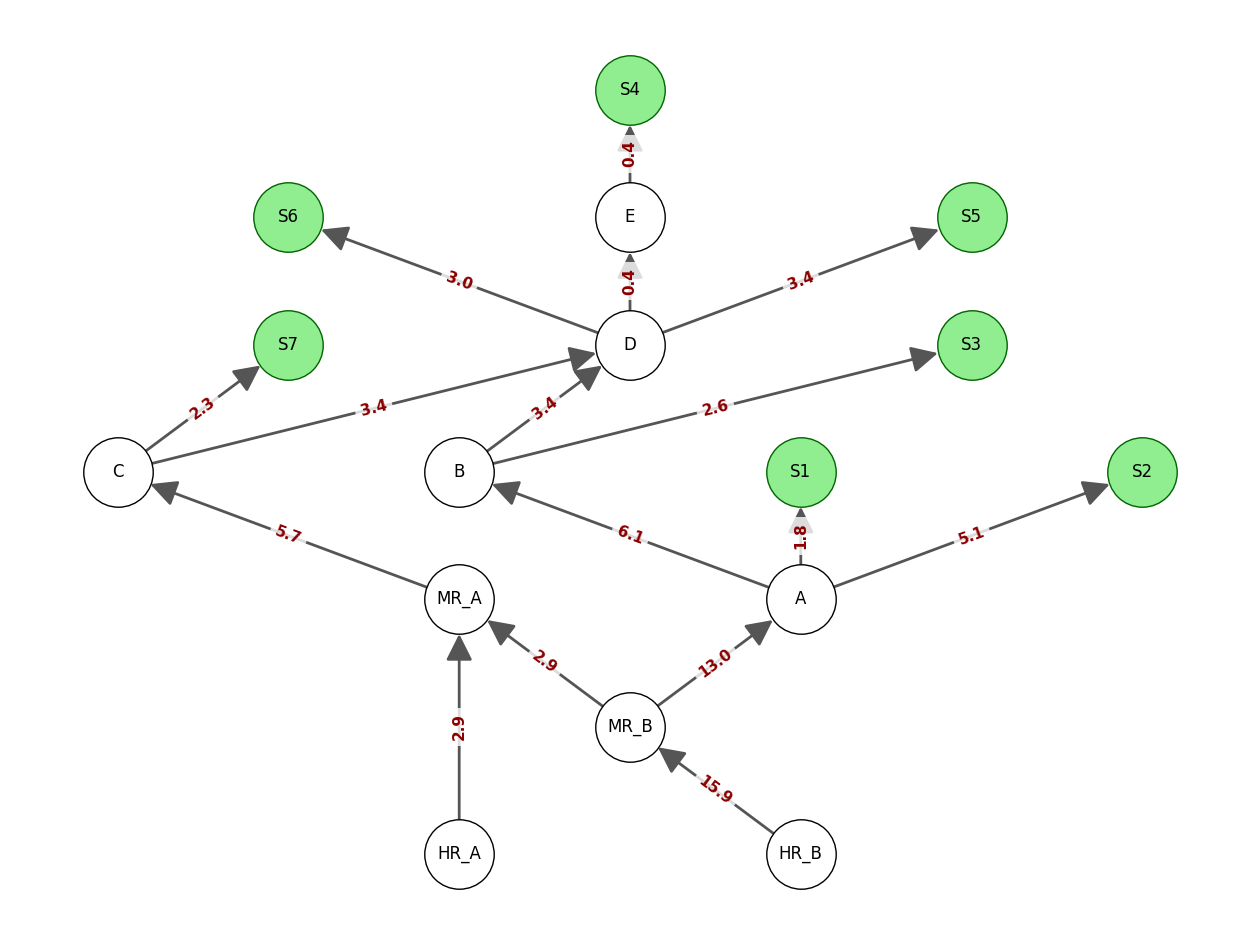

In [4]:
def create_skewed_series(n_points, max_val, skewness, sigma=1.0):
    """
    Generates a pandas Series of random numbers following a Skew Normal distribution,
    shifted so the maximum value equals 'max_val'.

    Args:
        n_points (int): The number of data points to generate.
        max_val (float): The maximum value (ceiling) of the dataset.
        skewness (float): The skew factor. 
                          0 = Normal distribution (symmetric).
                          Positive = Tail on the right (mass on left).
                          Negative = Tail on the left (mass on right).
        sigma (float): The scale (standard deviation) or 'width' of the curve.

    Returns:
        pd.Series: A Series containing the generated data.
    """
    # 1. Generate the raw Skew Normal distribution
    # 'a' is the skewness parameter
    # 'loc' is the mean, 'scale' is the standard deviation (sigma)
    raw_data = skewnorm.rvs(a=skewness, loc=0, scale=sigma, size=n_points)

    # 2. Shift the data to respect the 'max_val' constraint
    # We find the current generated max, and shift the whole dataset
    # so that the new max hits your target exactly.
    current_max = np.max(raw_data)
    shift_amount = max_val - current_max
    final_data = raw_data + shift_amount

    return pd.Series(final_data)
    
def create_day_demand(day:datetime, node:str, amp_range:int = (60, 100), skewness_range:int = (-6,-3), sigma_range:int = (7, 10), nn:int = 1440, points:int = 24):

    _max_val = random.randint(amp_range[0], amp_range[1])
    _skewness = random.randint(skewness_range[0], skewness_range[1])
    _sigma = random.randint(sigma_range[0], sigma_range[1])

    #print(f"Node: {node}, Max Val: {_max_val}, Skewness: {_skewness}, Sigma: {_sigma}")
    _curve = create_skewed_series(5000, _max_val, skewness=_skewness, sigma=_sigma)
    _curve = _curve.value_counts(bins=points).sort_index().reset_index(drop=True)
    _curve.name = node
    _curve.index = pd.date_range(start=day, periods=points, freq='h')
    _curve = _curve * _max_val/_curve.max()

    return _curve

def propagate_demand_upwards(G: nx.DiGraph, flow_attr='flow') -> nx.DiGraph:
    """
    Calculates flow for all edges in a DAG by propagating demand from 
    bottom leaf edges upwards to the top sources.
    
    Args:
        G: A NetworkX DiGraph (must be Acyclic).
           'Leaf edges' (edges pointing to nodes with out_degree=0) must 
           have the 'flow' attribute set.
        flow_attr: The attribute name for the flow value.
        
    Returns:
        The DiGraph with calculated flows on all edges.
    """
    # Work on a copy to preserve original structure
    H = G.copy()

    # 1. Verification: Ensure it is a DAG (Cycles break Kirchhoff's logic)
    if not nx.is_directed_acyclic_graph(H):
        raise ValueError("Graph contains a cycle. Kirchhoff propagation requires a DAG.")

    # 2. Initialize flow on non-leaf edges to 0 to be safe
    for u, v, data in H.edges(data=True):
        if flow_attr not in data:
            data[flow_attr] = 0.0

    # 3. Get Reverse Topological Sort
    # We process children before parents.
    # The last nodes in a topo sort are the leaves; reversed means we start with them.
    try:
        nodes_bottom_up = list(reversed(list(nx.topological_sort(H))))
    except nx.NetworkXUnfeasible:
        raise ValueError("Graph cycle detected during sort.")

    # 4. Propagate Flow Upwards
    for node in nodes_bottom_up:
        # Step A: Calculate how much this node OUTPUTS (Demand)
        out_edges = H.out_edges(node, data=True)
        
        # If it's a leaf node, it doesn't output to other nodes, 
        # but the edges *entering* it carry the flow we start with.
        # We need to calculate the flow for the edges ENTERING this node.
        
        # Calculate the total flow leaving this node
        total_out_flow = sum(data.get(flow_attr, 0.0) for _, _, data in out_edges)
        
        # NOTE: If this is a true "Leaf" (out_degree=0), total_out_flow is 0.
        # But wait - the prompt says "flow is attribute in the LEAF EDGES".
        # This implies the edges *entering* the leaves already have values.
        # So we actually need to process 'Internal Nodes' that feed these leaves.
        
        # If total_out_flow is 0, check if this node is a sink that was manually set?
        # No, the flow is on the *edge*. 
        # So if I am Node B, and I point to Leaf C (B->C), B->C has flow.
        # I just summed B->C. Now I need to supply B's parents.

        # Step B: Identify Parents (Incoming Edges)
        in_edges = list(H.in_edges(node))
        num_parents = len(in_edges)

        if num_parents > 0:
            # If the node has output flow, it must request that amount from inputs.
            # However, if this node is a Leaf, it has NO output edges.
            # But the edge pointing TO it (Parent->Leaf) is the one with the value.
            # We don't need to calculate the flow for the edge pointing to the leaf 
            # (it's already there). We need to calculate the flow for the Parent's Parent.
            
            # So, strictly speaking, we only need to act if we are an INTERNAL node
            # whose out-edges have just been summed up.
            
            # If total_out_flow > 0, we propagate it up.
            if total_out_flow > 0:
                flow_per_parent = total_out_flow / num_parents
                
                for parent, _ in in_edges:
                    # Set the flow for the incoming edge (Parent -> Node)
                    # We use += because a parent might have multiple children 
                    # causing it to accumulate demand from different branches.
                    # BUT: Since we initialize to 0 and visit each edge once from the child side,
                    # we can technically just set it, but += is safer for aggregation logic.
                    
                    current_val = H[parent][node].get(flow_attr, 0.0)
                    
                    # If this edge was a "leaf edge" preset by the user, we shouldn't overwrite it?
                    # The user said leaf edges have attributes. Upper edges don't.
                    # We only overwrite if it's 0 (calculated).
                    if current_val == 0.0:
                         H[parent][node][flow_attr] = flow_per_parent
                    else:
                        # If the edge already has flow (e.g., it's a leaf edge), 
                        # we use that value for the sum, but we don't change it.
                        pass

    return H

def draw_flow_graph_spaced(G, flow_attr='flow', spacing=2.0):
    plt.figure(figsize=(8 * spacing, 6 * spacing))
    
    # 1. Layout logic
    for layer, nodes in enumerate(nx.topological_generations(G)):
        for node in nodes: 
            G.nodes[node]['layer'] = layer
    pos = nx.multipartite_layout(G, subset_key='layer', align='horizontal', scale=spacing)

    # 2. Identify Nodes
    leaf_nodes = [n for n, d in G.out_degree() if d == 0]
    regular_nodes = [n for n in G.nodes() if n not in leaf_nodes]

    # 3. Draw Nodes (Draw these first)
    nx.draw_networkx_nodes(G, pos, nodelist=regular_nodes, node_size=2500, node_color='white', edgecolors='black')
    nx.draw_networkx_nodes(G, pos, nodelist=leaf_nodes, node_size=2500, node_color='lightgreen', edgecolors='darkgreen')
    nx.draw_networkx_labels(G, pos, font_size=12)

    # 4. Draw Edges (PUT ARROWS HERE)
    nx.draw_networkx_edges(
        G, pos, 
        node_size=2500,          # Tells arrows where to stop so they are visible
        arrows=True,              # Valid here
        arrowstyle='-|>',         # Solid triangle head
        arrowsize=40,             # Large enough to see
        edge_color='#555555', 
        width=2,
        min_target_margin=25      # Forces the arrow tip to stay outside the node circle
    )

    # 5. Draw Edge Labels (TEXT ONLY)
    edge_labels = {
        (u, v): f"{d[flow_attr]:.1f}" 
        for u, v, d in G.edges(data=True) if flow_attr in d
    }
    
    nx.draw_networkx_edge_labels(
        G, pos, 
        edge_labels=edge_labels, # No 'arrows' or 'arrow' argument here!
        font_color='darkred', 
        font_size=11, 
        font_weight='bold',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.8)
    )

    plt.axis('off')
    plt.show()

def draw_flow_graph_spaced_df(G,df):

    _attr = df.columns[-1]
    print(_attr)
   
    _h = nx.from_pandas_edgelist(df, 
                            source=0, 
                            target=1, 
                            edge_attr=True, 
                            create_using=nx.DiGraph()
                            )

    draw_flow_graph_spaced(_h, flow_attr=_attr)
    
def reconsruct_flows(G, flows:dict):
    H = G.copy()

    for _leaf_node,_flow in flows.items():
        _edge_leaf = [x for x in H.edges() if x[1] == _leaf_node]
        H.edges[_edge_leaf[0]]["flow"] = float(_flow)

    H = propagate_demand_upwards(H)
    return H



################# CREATING GRAPH #######################
G = nx.DiGraph()
G.add_edge('HR_A', 'MR_A', capacity=10000)
G.add_edge('HR_B', 'MR_B', capacity=10000)
G.add_edge('MR_B', 'MR_A', capacity=10000)
G.add_edge('MR_A', 'C', capacity=10000)

G.add_edge('C', 'D', capacity=10000)
G.add_edge('MR_B', 'A', capacity=10000)
G.add_edge('A', 'B', capacity=10000)
G.add_edge('B', 'D', capacity=10000)
G.add_edge('D', 'E', capacity=10000)

G.add_edge('C', 'S7', capacity=10000)
G.add_edge('D', 'S6', capacity=10000)
G.add_edge('D', 'S5', capacity=10000)
G.add_edge('B', 'S3', capacity=10000)
G.add_edge('A', 'S1', capacity=10000)
G.add_edge('A', 'S2', capacity=10000)
G.add_edge('E', 'S4', capacity=10000)

################# CREATING DEMANDS #######################

DEMANDS_NODES = ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7']
DAY_START = datetime(2024, 1, 1)
RANGE_MONTHS = 6
RANGE_DATE = pd.date_range(start=DAY_START, periods=RANGE_MONTHS*30, freq='D')


DEMANDS = []
for _day in RANGE_DATE:
    _demands_day = {}
    for _node in DEMANDS_NODES:
        _demands_day[_node] = create_day_demand(_day, _node)
    DEMANDS.append(pd.DataFrame(_demands_day))

DEMANDS = pd.concat(DEMANDS)


##### CREATING ROW DATA ###########################################
RAW_DATA = []
for _date,_flows in DEMANDS.iterrows():
    _flows_dict = _flows.to_dict()
    _flows_h = reconsruct_flows(G,_flows_dict).edges(data=True)
    _flows_df = pd.DataFrame([(x[0],x[1],x[2]['flow']) for x in _flows_h]).set_index([0,1]).rename(columns={2:_date}).T 
    RAW_DATA.append(_flows_df) 
    clear_output()
    print(_date)
clear_output()

RAW_DATA = pd.concat(RAW_DATA)

############################################## SIULATING NOISE
if WITH_NOISE:
    NOISE =  np.random.uniform(-0.05, 0.05,size=RAW_DATA.shape)
else:
    NOISE = 0
    
RAW_DATA = RAW_DATA*(1+NOISE)
RAW_DATA = RAW_DATA.T

## TEST FLOW
draw_flow_graph_spaced_df(G, RAW_DATA.T.sample(1).T.reset_index() )


<Axes: >

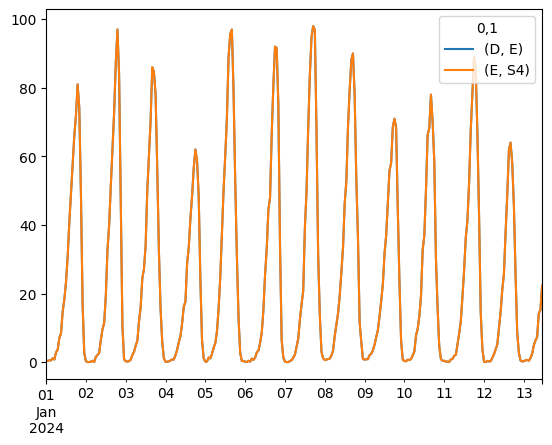

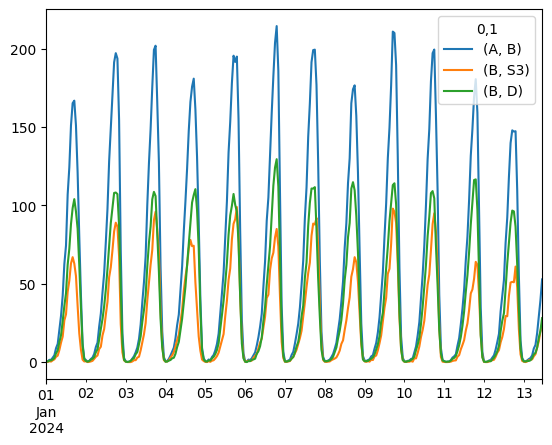

In [5]:
RAW_DATA.loc[[('D','E'),('E','S4')]].iloc[:,:300].T.plot()
RAW_DATA.loc[[('A','B'),('B','S3'),('B','D')]].iloc[:,:300].T.plot()

## PREPARATION OF DATA

In [6]:
SAMPLING = '1h'
TSS = RAW_DATA.T.copy()
TSS = TSS.resample(SAMPLING).mean()
TSS = TSS[TSS.index.month.isin(TSS.index.month.unique()[-8:])]
TSS.columns.names = ['from','to']

TSS

from                      HR_A        MR_A        HR_B       MR_B              \
to                        MR_A           C        MR_B       MR_A           A   
2024-01-01 00:00:00   0.259931    0.519863    1.537324   0.259931    1.277393   
2024-01-01 01:00:00   0.180093    0.360186    0.854421   0.180093    0.674328   
2024-01-01 02:00:00   0.684572    1.369144    2.614626   0.684572    1.930054   
2024-01-01 03:00:00   0.882291    1.764582    3.973526   0.882291    3.091235   
2024-01-01 04:00:00   1.674393    3.348786    7.502811   1.674393    5.828418   
...                        ...         ...         ...        ...         ...   
2024-06-28 19:00:00  91.888314  183.776627  389.500993  91.888314  297.612679   
2024-06-28 20:00:00  65.635488  131.270976  277.009920  65.635488  211.374432   
2024-06-28 21:00:00  38.410398   76.820795  137.220437  38.410398   98.810039   
2024-06-28 22:00:00  11.571040   23.142081   37.063483  11.571040   25.492443   
2024-06-28 23:00:00   2.088596    4.177192    5.903677   2.088596    3.815081   

from                          C                     D                        \
to                            D         S7          E         S6         S5   
2024-01-01 00:00:00    0.297974   0.221889   0.248848   0.246006   0.101093   
2024-01-01 01:00:00    0.360186   0.000000   0.373272   0.246006   0.101093   
2024-01-01 02:00:00    0.925365   0.443778   0.497696   1.353035   0.000000   
2024-01-01 03:00:00    1.098915   0.665667   0.497696   1.599042   0.101093   
2024-01-01 04:00:00    1.684618   1.664168   1.119816   1.845048   0.404372   
...                         ...        ...        ...        ...        ...   
2024-06-28 19:00:00  116.776627  67.000000  68.553254  83.000000  82.000000   
2024-06-28 20:00:00   71.737843  59.533133  32.121302  58.740050  52.614334   
2024-06-28 21:00:00   31.111458  45.709337   6.952663  33.860697  21.409556   
2024-06-28 22:00:00    7.905635  15.236446   0.973373  10.220149   4.617747   
2024-06-28 23:00:00    1.351890   2.825301   0.139053   1.445274   1.119454   

from                          A                                 B             \
to                            B         S1         S2           D         S3   
2024-01-01 00:00:00    0.503495   0.634146   0.139752    0.297974   0.205521   
2024-01-01 01:00:00    0.462946   0.211382   0.000000    0.360186   0.102761   
2024-01-01 02:00:00    1.439169   0.211382   0.279503    0.925365   0.513804   
2024-01-01 03:00:00    1.407197   0.845528   0.838509    1.098915   0.308282   
2024-01-01 04:00:00    2.814986   1.056911   1.956522    1.684618   1.130368   
...                         ...        ...        ...         ...        ...   
2024-06-28 19:00:00  185.031257  59.391111  53.190311  116.776627  68.254630   
2024-06-28 20:00:00  132.538769  47.226667  31.608997   71.737843  60.800926   
2024-06-28 21:00:00   67.528124  18.093333  13.188581   31.111458  36.416667   
2024-06-28 22:00:00   17.595450   4.191111   3.705882    7.905635   9.689815   
2024-06-28 23:00:00    2.629668   0.204444   0.980969    1.351890   1.277778   

from                         E  
to                          S4  
2024-01-01 00:00:00   0.248848  
2024-01-01 01:00:00   0.373272  
2024-01-01 02:00:00   0.497696  
2024-01-01 03:00:00   0.497696  
2024-01-01 04:00:00   1.119816  
...                        ...  
2024-06-28 19:00:00  68.553254  
2024-06-28 20:00:00  32.121302  
2024-06-28 21:00:00   6.952663  
2024-06-28 22:00:00   0.973373  
2024-06-28 23:00:00   0.139053  

[4320 rows x 16 columns]

In [7]:
print(f"Saving Data in {SAVE_PATH}")
RAW_DATA.to_parquet(SAVE_PATH)

Saving Data in Sim_Raw_data.parquet


c:\Users\valdo\anaconda3\envs\models3.11.3\Lib\site-packages\pandas\io\parquet.py:482: UserWarning: The DataFrame has non-str index name `[0, 1]` which will be converted to string and not roundtrip correctly.
  impl.write(
